# EXTEND DATA SCIENCE ASSESSMENT

### Requirements and Package Installs

In [91]:
pip install -r requirements.txt

You should consider upgrading via the '/Users/myrsmpb/Documents/extend_project/extend_env/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [92]:
import pandas as pd
import datetime as dt
import numpy as np
import seaborn as sb
import psycopg2 as p2
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


### Connect to PostegreSQL Server and Load Data

In [93]:
conn = p2.connect(dbname='postgres', user='postgres', password='password', port=5432)

cur=conn.cursor()

#### Grab the raw data for reference

In [ ]:
orders = pd.read_csv('data/orders.csv')
order_lines = pd.read_csv('data/order_lines.csv')
merchants = pd.read_csv('data/merchants.csv')
contracts = pd.read_csv('data/contracts.csv')

#### Get the data from the server

In [95]:
attachment = "SELECT * FROM extend.attachment;"
rank = "SELECT * FROM extend.rank;"

file_list = [attachment, rank]

In [96]:
for i, f in enumerate(file_list):
    if i == 0:
        xct = cur.execute(f)
        fetch_attach = cur.fetchall()
        cols = ['store_type','store_name','ordered_month','orders_count','items_count','items_total','contract_count'
                ,'warrantable_count','warranty_count','warranty_revenue','items_revenue']
        attachment_df = pd.DataFrame(fetch_attach, columns=cols)
    if i == 1:
        xct = cur.execute(f)
        fetch_rank = cur.fetchall()
        cols = ['store_name','store_type','warranty_revenue','order_count','extend_revenue'
                ,'warranty_rank','order_rank','extend_rank']
        rank_df = pd.DataFrame(fetch_rank, columns=cols)

attachment_df.to_csv("extend_attachment.csv", index=False)
rank_df.to_csv("extend_rank.csv", index=False)

In [97]:
attachment_df[attachment_df['warrantable_count'] / attachment_df['items_total'] > 1]

,store_type,store_name,ordered_month,orders_count,items_count,items_total,contract_count,warrantable_count,warranty_count,warranty_revenue,items_revenue


### Attachment Calculations

In [98]:
df = attachment_df.copy()

df['ordered_month'] = pd.to_datetime(df['ordered_month']).dt.tz_localize(None)

df['warranty_revenue'] = df['warranty_revenue'].astype(float).round(2)
df['items_revenue'] = df['items_revenue'].astype(float).round(2)

df['unit_attach_rate'] = (df['warrantable_count'] / df['items_total']).astype(float).round(2)
df['dollar_attach_rate'] = (df['warranty_revenue'] / df['items_revenue']).astype(float).round(2)

df = df.fillna(0)

### Visualization

#### Overall Performance

In [99]:
monthly = df.groupby('ordered_month').agg({
    'items_revenue' : 'sum'
    , 'warranty_revenue' : 'sum'
    , 'items_total' : 'sum'
    , 'warrantable_count' : 'sum'
}).reset_index().sort_values('ordered_month')

monthly['avg_units_attach'] = (monthly['warrantable_count'] / monthly['items_total']).astype(float).round(2)
monthly['avg_dollar_attach'] = (monthly['warranty_revenue'] / monthly['items_revenue']).astype(float).round(2)

/var/folders/9r/9rbrz58n5rjfd_6k7nmkdr9w0000gn/T/ipykernel_63845/529930596.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.lineplot(


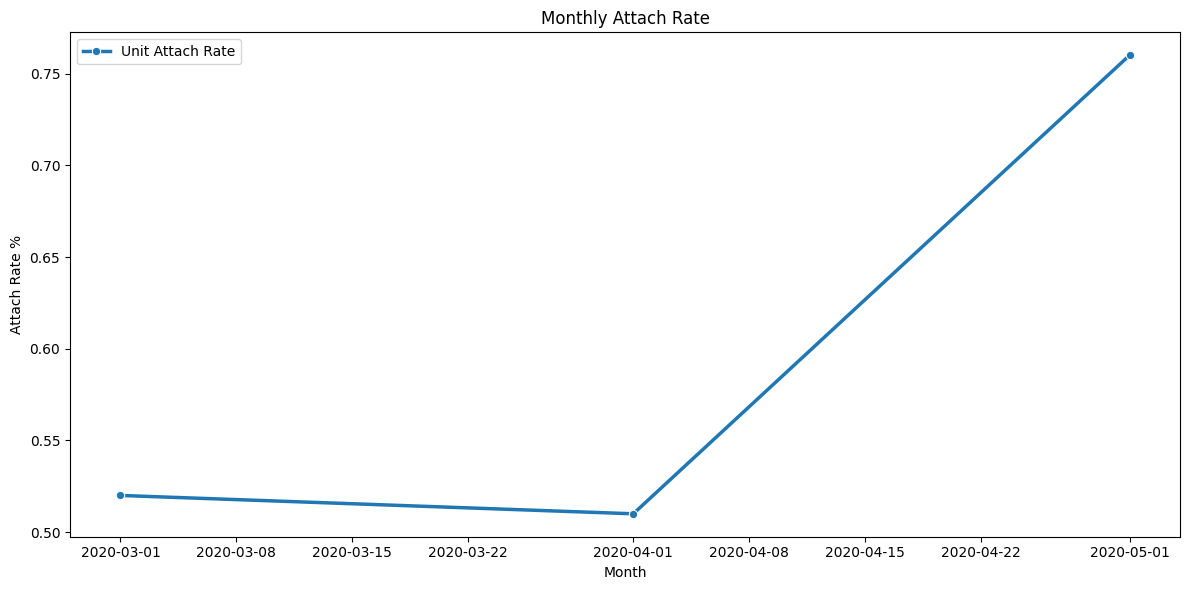

In [100]:
fig, axis1 = plt.subplots(figsize=(12,6))

sb.lineplot(
    data=monthly
    , x='ordered_month'
    , y='avg_units_attach'
    , palette='viridis'
    , label='Unit Attach Rate'
    , marker='o'
    , linewidth=2.5
    ,ax=axis1
)
axis1.set_ylabel('Attach Rate %')
axis1.set_xlabel('Month')

plt.title('Monthly Attach Rate')
fig.tight_layout()
plt.show()

/var/folders/9r/9rbrz58n5rjfd_6k7nmkdr9w0000gn/T/ipykernel_63845/2440502695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


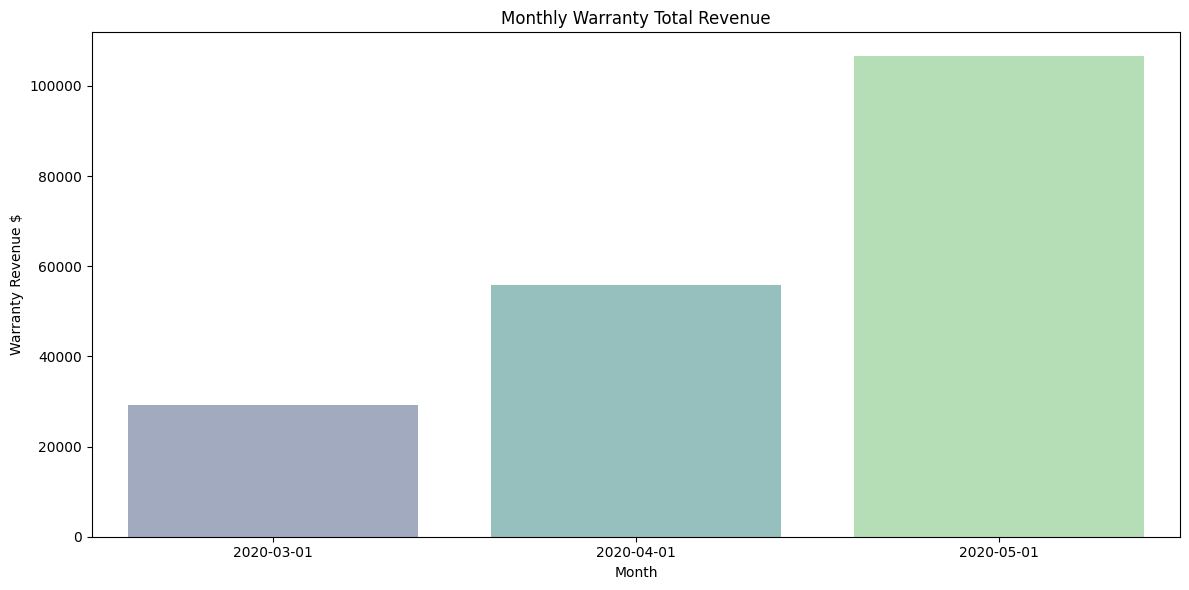

In [101]:
fig, axis2 = plt.subplots(figsize=(12,6))

sb.barplot(
    data=monthly
    , x='ordered_month'
    , y='warranty_revenue'
    , palette='viridis'
    , alpha=0.5
    , ax=axis2
    , label='Total Revenue'
)
axis2.set_ylabel('Warranty Revenue $')
axis2.set_xlabel('Month')

plt.title('Monthly Warranty Total Revenue')
fig.tight_layout()
plt.show()

In [102]:
industry_attach = df.groupby('store_type').agg({
    'items_revenue' : 'sum'
    , 'warranty_revenue' : 'sum'
    , 'items_total' : 'sum'
    , 'warrantable_count' : 'sum'
}).reset_index()

industry_attach['avg_units_attach'] = (industry_attach['warrantable_count'] / industry_attach['items_total']).astype(float)
industry_attach['avg_dollar_attach'] = (industry_attach['warranty_revenue'] / industry_attach['items_revenue']).astype(float)
industry_attach['warranty_revenue'] = industry_attach['warranty_revenue'].astype(float).round(2)

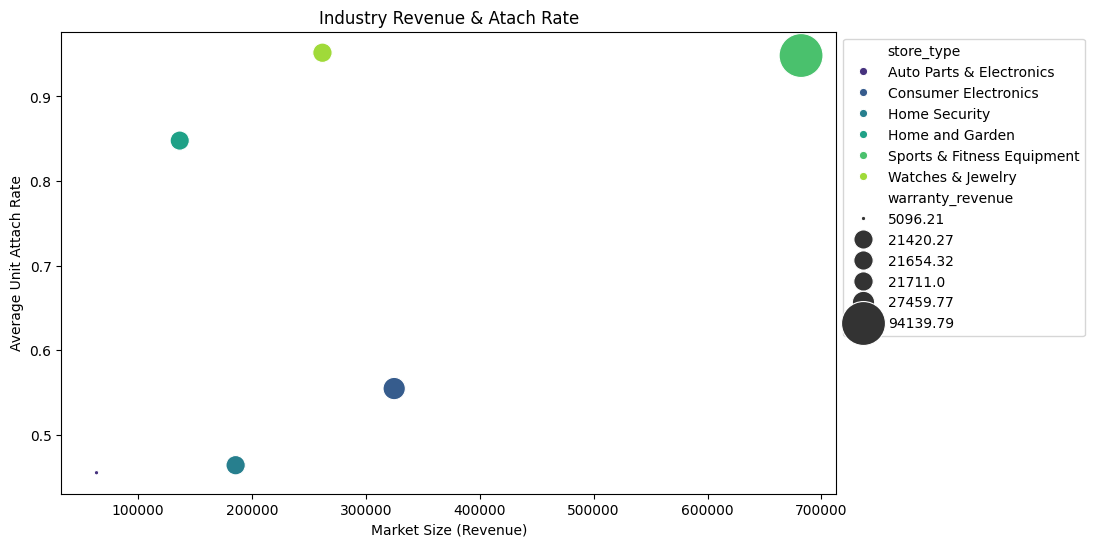

In [107]:
plt.figure(figsize=(10,6))
sb.scatterplot(
    data=industry_attach
    , x='items_revenue'
    , y='avg_units_attach'
    , size='warranty_revenue'
    , hue='store_type'
    , sizes=(10, 1000)
    , palette='viridis'
)

plt.title('Industry Revenue & Atach Rate')
plt.xlabel('Market Size (Revenue)')
plt.ylabel('Average Unit Attach Rate')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

df = rank_df.copy()

df['warranty_rank'] = df['warranty_rank'].astype(int)
df['warranty_revenue'] = df['warranty_revenue'].astype(float)
df['extend_rank'] = df['extend_rank'].astype(int)
df['extend_revenue'] = df['extend_revenue'].astype(float)

ranks = df.groupby('store_type').agg({
    'warranty_revenue' : 'sum'
    , 'warranty_rank' : 'mean'
}).sort_values('warranty_revenue', ascending=False).reset_index()

plt.figure(figsize=(10,6))

sb.barplot(data=ranks , x='warranty_revenue', y='store_type')

plt.show()

/var/folders/9r/9rbrz58n5rjfd_6k7nmkdr9w0000gn/T/ipykernel_63845/1663060110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(
/var/folders/9r/9rbrz58n5rjfd_6k7nmkdr9w0000gn/T/ipykernel_63845/1663060110.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05,1))


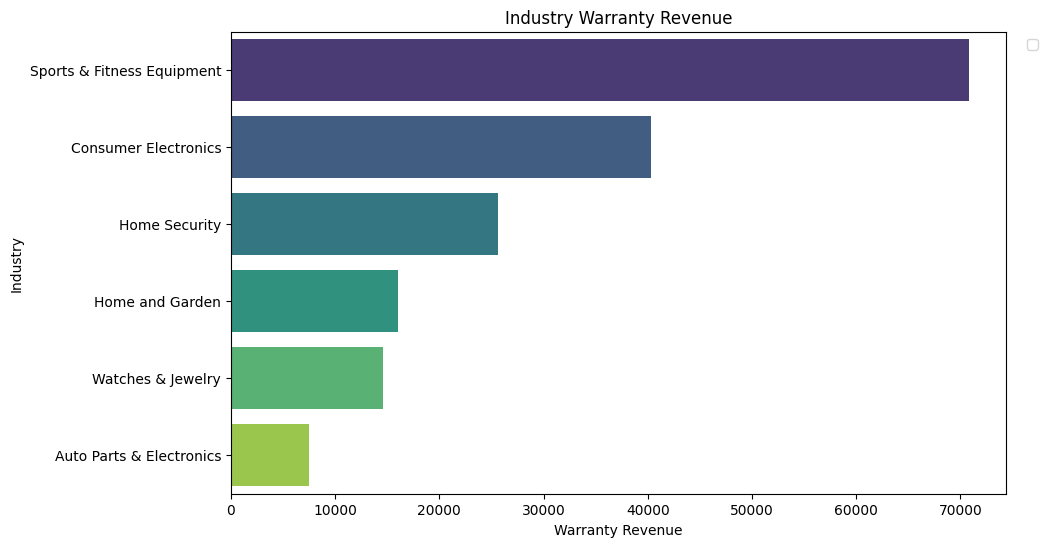

In [106]:
df = rank_df.copy()

ranks = df.groupby('store_type').agg({
    'extend_revenue' : 'sum'
    , 'extend_rank' : 'mean'
}).sort_values('extend_revenue', ascending=False).reset_index()

plt.figure(figsize=(10,6))

sb.barplot(
    data=ranks 
    , x='extend_revenue'
    , y='store_type'
    , palette='viridis'
)

plt.title('Industry Warranty Revenue')
plt.xlabel('Warranty Revenue')
plt.ylabel('Industry')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()